# Figure 2: Main Comparison Runner

This notebook generates Figure 2 from the paper using pretrained model logs.

**By default**, pretrained logs are used. Set `RETRAIN = True` to retrain all models from scratch.

In [1]:
import subprocess
import sys
from pathlib import Path
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
# =============================================================================
# Configuration
# =============================================================================
# Set to True to retrain all models instead of using pretrained logs
RETRAIN = False

In [3]:
# Get the repository root directory
# This notebook is at the root level of the PiDeeL repo
import os
REPO_ROOT = Path(os.getcwd())

# If running from within Jupyter, the cwd might be the notebook location
# Check if we're in the correct directory by looking for reproduction/
if not (REPO_ROOT / 'reproduction').exists():
    # Try to find PiDeeL in the path
    parts = REPO_ROOT.parts
    if 'PiDeeL' in parts:
        pideel_idx = parts.index('PiDeeL')
        REPO_ROOT = Path(*parts[:pideel_idx+1])
    else:
        # Use absolute path as fallback
        REPO_ROOT = Path('/mnt/disk90/user/gkaynar/PiDeeL')

# Reproduction directory contains all the scripts
REPRO_ROOT = REPO_ROOT / 'reproduction'

print(f"Repository root: {REPO_ROOT}")
print(f"Reproduction root: {REPRO_ROOT}")
print(f"RETRAIN mode: {RETRAIN}")

LOG_CHECKS = [
    # Baseline models
    ("logs/baseline/coxph/c_indices.txt", "scripts/baseline/coxph/main.py"),
    ("logs/baseline/cwgb/c_indices.txt", "scripts/baseline/cwgb/main.py"),
    ("logs/baseline/rf/c_indices.txt", "scripts/baseline/rf/main.py"),
    
    # 4-layer models (main PiDeeL vs DeepSurv)
    ("logs/4layer/no_pathway/c_indices.txt", "scripts/4layer/no_pathway/main.py"),
    ("logs/4layer/pathway/c_indices.txt", "scripts/4layer/pathway/main.py"),

    # DeepHit (from test29)
    ("test_logs/test29/4layer/no_pathway/c_indices.txt", "test_scripts/test29/4layer/no_pathway/main.py"),
    
    # PC-Hazard (from test30)
    ("test_logs/test30/4layer/no_pathway/c_indices.txt", "test_scripts/test30/4layer/no_pathway/main.py"),
]

Repository root: /mnt/disk90/user/gkaynar/PiDeeL
Reproduction root: /mnt/disk90/user/gkaynar/PiDeeL/reproduction
RETRAIN mode: False


In [4]:
def check_and_run_experiments():
    """Check for missing logs and run corresponding experiments."""
    script_to_logs = {}
    
    for log_path, script_path in LOG_CHECKS:
        # If RETRAIN is True, add all scripts to run
        # If RETRAIN is False, only add scripts for missing logs
        if RETRAIN or not (REPRO_ROOT / log_path).exists():
            if script_path not in script_to_logs:
                script_to_logs[script_path] = []
            script_to_logs[script_path].append(log_path)
    
    if script_to_logs:
        if RETRAIN:
            print(f"RETRAIN mode enabled. Running all {len(script_to_logs)} experiments...")
        else:
            print(f"Missing logs for {len(script_to_logs)} experiments. Running...")
        
        for script_path, logs in script_to_logs.items():
            full_script = REPRO_ROOT / script_path
            print(f"\n{'='*60}")
            print(f"Running: {script_path}")
            print(f"{'='*60}\n")
            try:
                subprocess.run(
                    [sys.executable, str(full_script)],
                    check=True,
                    cwd=str(full_script.parent)
                )
                print(f"✓ Generated logs for {Path(script_path).parent.name}")
            except subprocess.CalledProcessError as e:
                print(f"✗ Failed to run {script_path}")
                print(f"  Error: {e}")
                return False
    else:
        print("✓ All required logs exist (using pretrained logs)")
    
    return True

In [5]:
def plot_figure():
    """Run the figure plotting script."""
    print(f"\n{'='*60}")
    print("Generating Figure 2: Main Comparison")
    print(f"{'='*60}\n")
    
    script = REPRO_ROOT / "figures" / "fig2_main_comparison.py"
    try:
        subprocess.run(
            [sys.executable, str(script)],
            check=True,
            cwd=str(script.parent)
        )
        print("\n✓ Figure 2 generated successfully!")
        print(f"  Output: reproduction/figures/fig2_main_comparison.png")
        print(f"  Output: reproduction/figures/fig2_main_comparison.pdf")
        return True
    except subprocess.CalledProcessError as e:
        print(f"\n✗ Failed to generate figure")
        print(f"  Error: {e}")
        return False

In [6]:
def display_figure():
    """Display the generated figure in the notebook."""
    fig_path = REPRO_ROOT / "figures" / "fig2_main_comparison.png"
    
    if fig_path.exists():
        print(f"\nDisplaying figure from: {fig_path}")
        # Load and display the image
        img = mpimg.imread(str(fig_path))
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n⚠ Figure file not found: {fig_path}")

## Run the Main Workflow

Figure 2 Runner: Main Comparison
✓ All required logs exist (using pretrained logs)

Generating Figure 2: Main Comparison

Figure saved to /mnt/disk90/user/gkaynar/PiDeeL/reproduction/figures/fig2_main_comparison.png
Figure saved to /mnt/disk90/user/gkaynar/PiDeeL/reproduction/figures/fig2_main_comparison.pdf

✓ Figure 2 generated successfully!
  Output: reproduction/figures/fig2_main_comparison.png
  Output: reproduction/figures/fig2_main_comparison.pdf

Displaying figure from: /mnt/disk90/user/gkaynar/PiDeeL/reproduction/figures/fig2_main_comparison.png


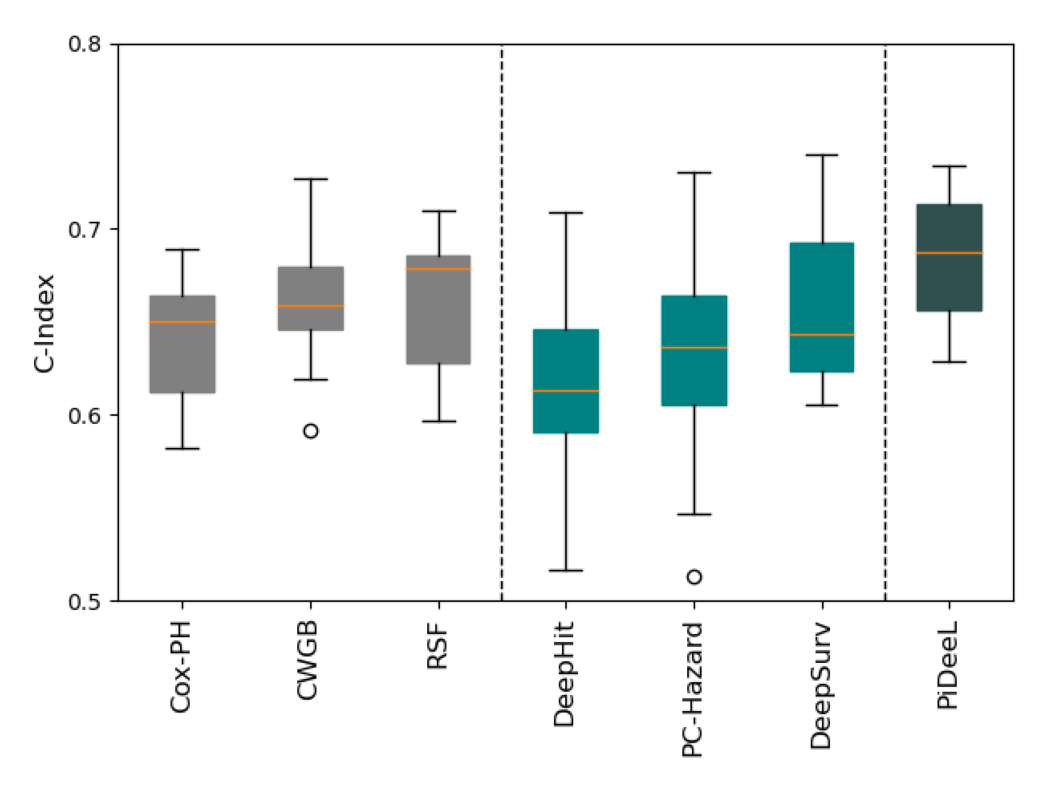

In [7]:
print("="*60)
print("Figure 2 Runner: Main Comparison")
print("="*60)

if check_and_run_experiments():
    if plot_figure():
        display_figure()